# Loading and Preprocessing:

In [90]:
import pandas as pd
G_train = pd.read_csv("GoEmotions/Processed/GoEmotions_train.csv")
G_test = pd.read_csv("GoEmotions/Processed/GoEmotions_test.csv")

S_train = pd.read_csv("SemEvalDataset/processed/train.csv")
S_test = pd.read_csv("SemEvalDataset/processed/test.csv")

T_train = pd.read_csv("TwitterEmotions/training.csv")
T_test = pd.read_csv("TwitterEmotions/test.csv")

In [91]:
G_train = G_train.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})
G_test = G_test.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})

In [92]:
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

def parse_labels(label_str):
    return [int(x) for x in str(label_str).split(",")]

def make_multilabel_columns(df):
    df = df.copy()

    # Convert "13,18" into [13, 18]
    df["label_list"] = df["label_id"].apply(parse_labels)

    # Add readable labels: [13,18] -> ["excitement", "love"]
    df["label_names"] = df["label_list"].apply(
        lambda ids: [emotions[i] for i in ids]
    )

    # Create one binary column per emotion
    for i, emotion in enumerate(emotions):
        df[emotion] = df["label_list"].apply(lambda labels: 1 if i in labels else 0)

    return df

G_train = make_multilabel_columns(G_train)
G_test = make_multilabel_columns(G_test)

# print(goemotions_train[["label_id", "label_list", "label_names"]].head())

emotion_cols = emotions
print(G_train.columns)

Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')


In [93]:
S_emotion_cols = [
    "anger", "anticipation", "disgust", "fear", "joy",
    "love", "optimism", "pessimism", "sadness", "surprise", "trust"
]

T_emotion_cols = ["sadness", "joy", "love", "anger", "fear", "surprise"]

In [94]:
T_emotion_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

T_train["emotion"] = T_train["label"].map(T_emotion_map)
T_test["emotion"] = T_test["label"].map(T_emotion_map)

for emotion in T_emotion_cols:
    T_train[emotion] = (T_train["emotion"] == emotion).astype(int)
    T_test[emotion] = (T_test["emotion"] == emotion).astype(int)

In [95]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    return re.findall(r"\b[a-z]+\b", clean_text(text))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

def pad_tokens(tokens, max_len=100, padding="post"):
    tokens = tokens[:max_len]
    pad_amount = max_len - len(tokens)

    if padding == "post":
        return tokens + ["<PAD>"] * pad_amount
    return ["<PAD>"] * pad_amount + tokens

In [96]:
S_train.columns = S_train.columns.str.strip()
S_test.columns = S_test.columns.str.strip()

from sklearn.model_selection import train_test_split

# Remove unlabeled examples first
S_labeled = S_train[
    S_train[S_emotion_cols].sum(axis=1) > 0
].reset_index(drop=True)

# Create your own train/test split
S_train, S_test = train_test_split(
    S_labeled,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

S_train[S_emotion_cols] = (
    S_train[S_emotion_cols]
    .replace("NONE", 0)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

S_test[S_emotion_cols] = (
    S_test[S_emotion_cols]
    .replace("NONE", 0)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

In [97]:
def label_statistics(df, label_cols, name):
    row_sums = df[label_cols].sum(axis=1)

    unlabeled = (row_sums == 0).sum()
    labeled = (row_sums > 0).sum()

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Total samples:           {len(df):,}")
    print(f"Labeled samples:         {labeled:,} ({100*labeled/len(df):.2f}%)")
    print(f"Unlabeled samples:       {unlabeled:,} ({100*unlabeled/len(df):.2f}%)")
    print(f"Average labels/sample:   {row_sums.mean():.3f}")

# # GoEmotions
# label_statistics(G_train, emotions, "GoEmotions Train")
# label_statistics(G_test, emotions, "GoEmotions Test")

# SemEval
label_statistics(S_train, S_emotion_cols, "SemEval Train")
label_statistics(S_test, S_emotion_cols, "SemEval Test")

# # Twitter
# label_statistics(T_train, T_emotion_cols, "Twitter Train")
# label_statistics(T_test, T_emotion_cols, "Twitter Test")


SemEval Train
-------------
Total samples:           5,307
Labeled samples:         5,307 (100.00%)
Unlabeled samples:       0 (0.00%)
Average labels/sample:   2.421

SemEval Test
------------
Total samples:           1,327
Labeled samples:         1,327 (100.00%)
Unlabeled samples:       0 (0.00%)
Average labels/sample:   2.412


In [98]:
def preprocess_only(df, text_col, max_len=100):
    df = df.copy()

    df["clean_text"] = df[text_col].apply(clean_text)

    df["tokens"] = df[text_col].apply(tokenize_text)

    df["tokens_no_stopwords"] = df["tokens"].apply(remove_stopwords)

    df["padded_tokens"] = df["tokens_no_stopwords"].apply(
        lambda tokens: pad_tokens(tokens, max_len=max_len, padding="post")
    )

    df["word_count"] = df["tokens"].apply(len)
    df["clean_word_count"] = df["tokens_no_stopwords"].apply(len)
    df["char_count"] = df["clean_text"].apply(len)

    return df

T_train = preprocess_only(T_train, text_col="text", max_len=100)
T_test = preprocess_only(T_test, text_col="text", max_len=100)

S_train = preprocess_only(S_train, text_col="Tweet", max_len=100)
S_test = preprocess_only(S_test, text_col="Tweet", max_len=100)

G_train = preprocess_only(G_train, text_col="text", max_len=100)
G_test = preprocess_only(G_test, text_col="text", max_len=100)

In [99]:
print(G_train.columns)
print(T_train.columns)
print(S_train.columns)

Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'clean_text',
       'tokens', 'tokens_no_stopwords', 'padded_tokens', 'word_count',
       'clean_word_count', 'char_count'],
      dtype='str')
Index(['text', 'label', 'emotion', 'sadness', 'joy', 'love', 'anger', 'fear',
       'surprise', 'clean_text', 'tokens', 'tokens_no_stopwords',
       'padded_tokens', 'word_count', 'clean_word_count', 'char_count'],
      dtype='str')
Index(['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy',
       'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust',
       'clean_text', 'tokens', 'tok

In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

metadata_cols = ["clean_word_count", "char_count"]

def build_features(train_df, test_df, text_col="clean_text", metadata_cols=metadata_cols):
    vectorizer = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    X_train_text = vectorizer.fit_transform(train_df[text_col])
    X_test_text = vectorizer.transform(test_df[text_col])

    scaler = StandardScaler()

    X_train_meta = scaler.fit_transform(train_df[metadata_cols])
    X_test_meta = scaler.transform(test_df[metadata_cols])

    X_train = hstack([X_train_text, csr_matrix(X_train_meta)])
    X_test = hstack([X_test_text, csr_matrix(X_test_meta)])

    return X_train, X_test, vectorizer, scaler

In [107]:
# GoEmotions
G_X_train, G_X_test, G_vectorizer, G_scaler = build_features(
    G_train,
    G_test
)

G_Y_train = G_train[emotions]
G_Y_test = G_test[emotions]


# GoEmotions
S_X_train, S_X_test, S_vectorizer, S_scaler = build_features(
    S_train,
    S_test
)

S_Y_train = S_train[S_emotion_cols]
S_Y_test = S_test[S_emotion_cols]


# Twitter
T_X_train, T_X_test, T_vectorizer, T_scaler = build_features(
    T_train,
    T_test
)

T_Y_train = T_train[T_emotion_cols]
T_Y_test = T_test[T_emotion_cols]

# Model Training

In [103]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

In [104]:
import time
import pandas as pd
import numpy as np
from sklearn.utils.multiclass import type_of_target

from sklearn.base import clone
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss
)

def train_evaluate_model_on_all_datasets(model, model_name, datasets):
    results = {}

    for dataset_name, data in datasets.items():
        print(f"\nTraining {model_name} on {dataset_name}...")

        X_train = data["X_train"]
        X_test = data["X_test"]

        Y_train = data["Y_train"].astype(int)
        Y_test = data["Y_test"].astype(int)

        current_model = clone(model)

        start_train = time.time()
        current_model.fit(X_train, Y_train)
        training_time = time.time() - start_train

        start_inference = time.time()
        Y_pred = current_model.predict(X_test)
        inference_time = time.time() - start_inference

        Y_test_array = Y_test.to_numpy()
        Y_pred_array = np.asarray(Y_pred).astype(int)

        print("Y_test type:", type_of_target(Y_test_array))
        print("Y_pred type:", type_of_target(Y_pred_array))

        results[dataset_name] = {
            "Micro F1": f1_score(Y_test_array, Y_pred_array, average="micro", zero_division=0),
            "Macro F1": f1_score(Y_test_array, Y_pred_array, average="macro", zero_division=0),
            "Micro Precision": precision_score(Y_test_array, Y_pred_array, average="micro", zero_division=0),
            "Micro Recall": recall_score(Y_test_array, Y_pred_array, average="micro", zero_division=0),
            "Hamming Loss": hamming_loss(Y_test_array, Y_pred_array),
            "Exact Match Accuracy": accuracy_score(Y_test_array, Y_pred_array),
            "Training Time (s)": training_time,
            "Inference Time (s)": inference_time
        }

    results_df = pd.DataFrame(results)

    print(f"\n===== {model_name} Performance Across Datasets =====")
    display(results_df)

    return results_df

In [105]:
datasets = {
    "GoEmotions": {
        "X_train": G_X_train,
        "X_test": G_X_test,
        "Y_train": G_Y_train,
        "Y_test": G_Y_test
    },
    "SemEval": {
        "X_train": S_X_train,
        "X_test": S_X_test,
        "Y_train": S_Y_train,
        "Y_test": S_Y_test
    },
    "Twitter": {
        "X_train": T_X_train,
        "X_test": T_X_test,
        "Y_train": T_Y_train,
        "Y_test": T_Y_test
    }
}

## Logistic Regression

In [106]:
log_reg_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced"
    )
)

log_reg_results = train_evaluate_model_on_all_datasets(
    model=log_reg_model,
    model_name="Logistic Regression",
    datasets=datasets
)


Training Logistic Regression on GoEmotions...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Logistic Regression on SemEval...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Logistic Regression on Twitter...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

===== Logistic Regression Performance Across Datasets =====


,GoEmotions,SemEval,Twitter
Micro F1,0.495189,0.610567,0.861118
Macro F1,0.434432,0.520076,0.823302
Micro Precision,0.389715,0.581566,0.827570
Micro Recall,0.678938,0.642612,0.897500
Hamming Loss,0.057655,0.179763,0.048250
Exact Match Accuracy,0.229777,0.159005,0.771500
Training Time (s),6.585572,0.210217,0.440258
Inference Time (s),0.008817,0.001907,0.001494


## Random Forest

In [108]:
rf_model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=30,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
)

rf_results = train_evaluate_model_on_all_datasets(
    model=rf_model,
    model_name="Random Forest",
    datasets=datasets
)


Training Random Forest on GoEmotions...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Random Forest on SemEval...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Random Forest on Twitter...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

===== Random Forest Performance Across Datasets =====


,GoEmotions,SemEval,Twitter
Micro F1,0.458652,0.579786,0.821554
Macro F1,0.365810,0.479547,0.750277
Micro Precision,0.366717,0.604131,0.823618
Micro Recall,0.612103,0.557326,0.819500
Hamming Loss,0.060182,0.177160,0.059333
Exact Match Accuracy,0.223696,0.154484,0.720000
Training Time (s),31.270737,2.979670,2.764883
Inference Time (s),1.022646,0.211999,0.124499


## SVM

In [109]:
svm_model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced",
        max_iter=5000
    )
)

svm_results = train_evaluate_model_on_all_datasets(
    model=svm_model,
    model_name="Linear SVM",
    datasets=datasets
)


Training Linear SVM on GoEmotions...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Linear SVM on SemEval...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Linear SVM on Twitter...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

===== Linear SVM Performance Across Datasets =====


,GoEmotions,SemEval,Twitter
Micro F1,0.499399,0.597407,0.871208
Macro F1,0.405185,0.494266,0.823623
Micro Precision,0.451894,0.597500,0.866469
Micro Recall,0.558066,0.597313,0.876000
Hamming Loss,0.046599,0.176543,0.043167
Exact Match Accuracy,0.290768,0.159005,0.806000
Training Time (s),12.718084,1.238887,3.052439
Inference Time (s),0.008280,0.001968,0.001602


## Naive Bayes

In [110]:
def build_nb_features(train_df, test_df, text_col="clean_text", metadata_cols=metadata_cols):
    vectorizer = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    X_train_text = vectorizer.fit_transform(train_df[text_col])
    X_test_text = vectorizer.transform(test_df[text_col])

    # raw metadata, NOT standardized
    X_train_meta = csr_matrix(train_df[metadata_cols].values)
    X_test_meta = csr_matrix(test_df[metadata_cols].values)

    # text + metadata
    X_train_nb = hstack([X_train_text, X_train_meta])
    X_test_nb = hstack([X_test_text, X_test_meta])

    return X_train_nb, X_test_nb, X_train_text, X_test_text, vectorizer

G_X_train_nb, G_X_test_nb, G_train_text, G_test_text, G_nb_vectorizer = build_nb_features(
    G_train, G_test
)

S_X_train_nb, S_X_test_nb, S_train_text, S_test_text, S_nb_vectorizer = build_nb_features(
    S_train, S_test
)

T_X_train_nb, T_X_test_nb, T_train_text, T_test_text, T_nb_vectorizer = build_nb_features(
    T_train, T_test
)

In [111]:
nb_datasets = {
    "GoEmotions": {
        "X_train": G_train_text,
        "X_test": G_test_text,
        "Y_train": G_Y_train,
        "Y_test": G_Y_test
    },
    "SemEval": {
        "X_train": S_train_text,
        "X_test": S_test_text,
        "Y_train": S_Y_train,
        "Y_test": S_Y_test
    },
    "Twitter": {
        "X_train": T_train_text,
        "X_test": T_test_text,
        "Y_train": T_Y_train,
        "Y_test": T_Y_test
    }
}

In [112]:
nb_model = OneVsRestClassifier(
    MultinomialNB()
)

nb_results = train_evaluate_model_on_all_datasets(
    model=nb_model,
    model_name="Naive Bayes",
    datasets=nb_datasets
)


Training Naive Bayes on GoEmotions...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Naive Bayes on SemEval...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

Training Naive Bayes on Twitter...
Y_test type: multilabel-indicator
Y_pred type: multilabel-indicator

===== Naive Bayes Performance Across Datasets =====


,GoEmotions,SemEval,Twitter
Micro F1,0.097496,0.296507,0.415451
Macro F1,0.029612,0.168090,0.217490
Micro Precision,0.783333,0.862952,0.981378
Micro Recall,0.051983,0.179007,0.263500
Hamming Loss,0.040084,0.186271,0.123583
Exact Match Accuracy,0.053437,0.082140,0.263500
Training Time (s),0.271264,0.027383,0.031363
Inference Time (s),0.033470,0.005118,0.004299


## Labels vs Performance

In [113]:
models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Linear SVM": svm_model,
    "Naive Bayes": nb_model
}

metrics_to_plot = [
    "Micro F1",
    "Macro F1",
    "Micro Precision",
    "Micro Recall",
    "Exact Match Accuracy"
]

In [138]:
def run_label_count_experiment(
    train_df,
    test_df,
    label_cols,
    dataset_name,
    text_col="clean_text",
    min_train_samples=30,
    min_test_samples=10
):
    all_results = {}

    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df["num_labels"] = train_df[label_cols].sum(axis=1)
    test_df["num_labels"] = test_df[label_cols].sum(axis=1)

    max_labels = int(
        max(
            train_df["num_labels"].max(),
            test_df["num_labels"].max()
        )
    )

    label_counts = list(range(1, max_labels + 1))

    print(f"\n==============================")
    print(f"{dataset_name}: Label Count Experiment")
    print(f"Label counts found: {label_counts}")
    print(f"==============================")

    for model_name, model in models.items():

        print(f"\nRunning model: {model_name}")

        model_rows = []

        for k in label_counts:

            train_k = train_df[train_df["num_labels"] == k].copy()
            test_k = test_df[test_df["num_labels"] == k].copy()

            if len(train_k) < min_train_samples or len(test_k) < min_test_samples:
                print(
                    f"Skipping {dataset_name}, {model_name}, {k} labels "
                    f"(train={len(train_k)}, test={len(test_k)})"
                )
                continue

            Y_train = train_k[label_cols].astype(int)
            Y_test = test_k[label_cols].astype(int)

            # Naive Bayes should use non-negative TF-IDF features only.
            # Other models use TF-IDF + metadata from your existing build_features().
            if model_name == "Naive Bayes":
                X_train, X_test, _, _, _ = build_nb_features(
                    train_k,
                    test_k,
                    text_col=text_col
                )
            else:
                X_train, X_test, _, _ = build_features(
                    train_k,
                    test_k,
                    text_col=text_col
                )

            current_model = clone(model)

            start_train = time.time()
            current_model.fit(X_train, Y_train)
            training_time = time.time() - start_train

            start_inference = time.time()
            Y_pred = current_model.predict(X_test)
            inference_time = time.time() - start_inference

            Y_test_array = Y_test.to_numpy()
            Y_pred_array = np.asarray(Y_pred).astype(int)

            row = {
                "Num Labels": k,
                "Train Samples": len(train_k),
                "Test Samples": len(test_k),

                "Micro F1": f1_score(
                    Y_test_array,
                    Y_pred_array,
                    average="micro",
                    zero_division=0
                ),

                "Macro F1": f1_score(
                    Y_test_array,
                    Y_pred_array,
                    average="macro",
                    zero_division=0
                ),

                "Micro Precision": precision_score(
                    Y_test_array,
                    Y_pred_array,
                    average="micro",
                    zero_division=0
                ),

                "Micro Recall": recall_score(
                    Y_test_array,
                    Y_pred_array,
                    average="micro",
                    zero_division=0
                ),

                "Hamming Loss": hamming_loss(
                    Y_test_array,
                    Y_pred_array
                ),

                "Exact Match Accuracy": accuracy_score(
                    Y_test_array,
                    Y_pred_array
                ),

                "Training Time (s)": training_time,
                "Inference Time (s)": inference_time
            }

            model_rows.append(row)

            print(
                f"{model_name} | {k} labels | "
                f"train={len(train_k)} test={len(test_k)} | "
                f"Micro F1={row['Micro F1']:.3f}"
            )

        all_results[model_name] = pd.DataFrame(model_rows)

    return all_results


In [139]:
G_label_count_results = run_label_count_experiment(
    train_df=G_train,
    test_df=G_test,
    label_cols=emotions,
    dataset_name="GoEmotions",
    text_col="clean_text"
)



GoEmotions: Label Count Experiment
Label counts found: [1, 2, 3, 4, 5]

Running model: Logistic Regression
Logistic Regression | 1 labels | train=36308 test=4590 | Micro F1=0.514
Logistic Regression | 2 labels | train=6541 test=774 | Micro F1=0.510
Logistic Regression | 3 labels | train=532 test=61 | Micro F1=0.364
Skipping GoEmotions, Logistic Regression, 4 labels (train=28, test=2)
Skipping GoEmotions, Logistic Regression, 5 labels (train=1, test=0)

Running model: Random Forest
Random Forest | 1 labels | train=36308 test=4590 | Micro F1=0.481
Random Forest | 2 labels | train=6541 test=774 | Micro F1=0.466
Random Forest | 3 labels | train=532 test=61 | Micro F1=0.311
Skipping GoEmotions, Random Forest, 4 labels (train=28, test=2)
Skipping GoEmotions, Random Forest, 5 labels (train=1, test=0)

Running model: Linear SVM
Linear SVM | 1 labels | train=36308 test=4590 | Micro F1=0.519
Linear SVM | 2 labels | train=6541 test=774 | Micro F1=0.496
Linear SVM | 3 labels | train=532 test=61 |

In [140]:
S_label_count_results = run_label_count_experiment(
    train_df=S_train,
    test_df=S_test,
    label_cols=S_emotion_cols,
    dataset_name="SemEval",
    text_col="clean_text"
)


SemEval: Label Count Experiment
Label counts found: [1, 2, 3, 4, 5, 6]

Running model: Logistic Regression
Logistic Regression | 1 labels | train=779 test=203 | Micro F1=0.551


/Users/varunpanuganti/Desktop/NSF-REU-Project/venv/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 10 is present in all training examples.
  warnings.warn(


Logistic Regression | 2 labels | train=2223 test=550 | Micro F1=0.622
Logistic Regression | 3 labels | train=1698 test=416 | Micro F1=0.626
Logistic Regression | 4 labels | train=517 test=141 | Micro F1=0.590
Logistic Regression | 5 labels | train=80 test=16 | Micro F1=0.528
Skipping SemEval, Logistic Regression, 6 labels (train=10, test=1)

Running model: Random Forest
Random Forest | 1 labels | train=779 test=203 | Micro F1=0.468
Random Forest | 2 labels | train=2223 test=550 | Micro F1=0.601
Random Forest | 3 labels | train=1698 test=416 | Micro F1=0.587
Random Forest | 4 labels | train=517 test=141 | Micro F1=0.508
Random Forest | 5 labels | train=80 test=16 | Micro F1=0.527
Skipping SemEval, Random Forest, 6 labels (train=10, test=1)

Running model: Linear SVM
Linear SVM | 1 labels | train=779 test=203 | Micro F1=0.539


/Users/varunpanuganti/Desktop/NSF-REU-Project/venv/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 10 is present in all training examples.
  warnings.warn(


Linear SVM | 2 labels | train=2223 test=550 | Micro F1=0.615
Linear SVM | 3 labels | train=1698 test=416 | Micro F1=0.617
Linear SVM | 4 labels | train=517 test=141 | Micro F1=0.615
Linear SVM | 5 labels | train=80 test=16 | Micro F1=0.509
Skipping SemEval, Linear SVM, 6 labels (train=10, test=1)

Running model: Naive Bayes
Naive Bayes | 1 labels | train=779 test=203 | Micro F1=0.029


/Users/varunpanuganti/Desktop/NSF-REU-Project/venv/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 10 is present in all training examples.
  warnings.warn(


Naive Bayes | 2 labels | train=2223 test=550 | Micro F1=0.085
Naive Bayes | 3 labels | train=1698 test=416 | Micro F1=0.306
Naive Bayes | 4 labels | train=517 test=141 | Micro F1=0.482
Naive Bayes | 5 labels | train=80 test=16 | Micro F1=0.608
Skipping SemEval, Naive Bayes, 6 labels (train=10, test=1)


In [141]:
import matplotlib.pyplot as plt

def plot_metric_vs_num_labels(results_dict, dataset_name, metrics):

    for metric in metrics:

        plt.figure(figsize=(9, 6))

        for model_name, results_df in results_dict.items():

            if results_df.empty:
                continue

            plt.plot(
                results_df["Num Labels"],
                results_df[metric],
                marker="o",
                label=model_name
            )

        plt.title(f"{dataset_name}: {metric} vs Number of Labels")
        plt.xlabel("Number of Labels Assigned")
        plt.ylabel(metric)
        plt.xticks(
            sorted(
                set(
                    np.concatenate([
                        df["Num Labels"].values
                        for df in results_dict.values()
                        if not df.empty
                    ])
                )
            )
        )
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


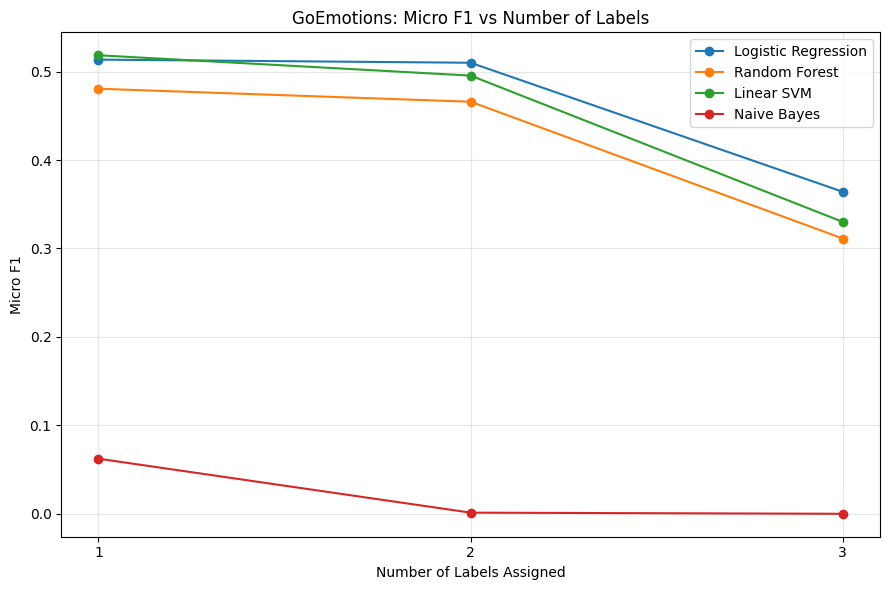

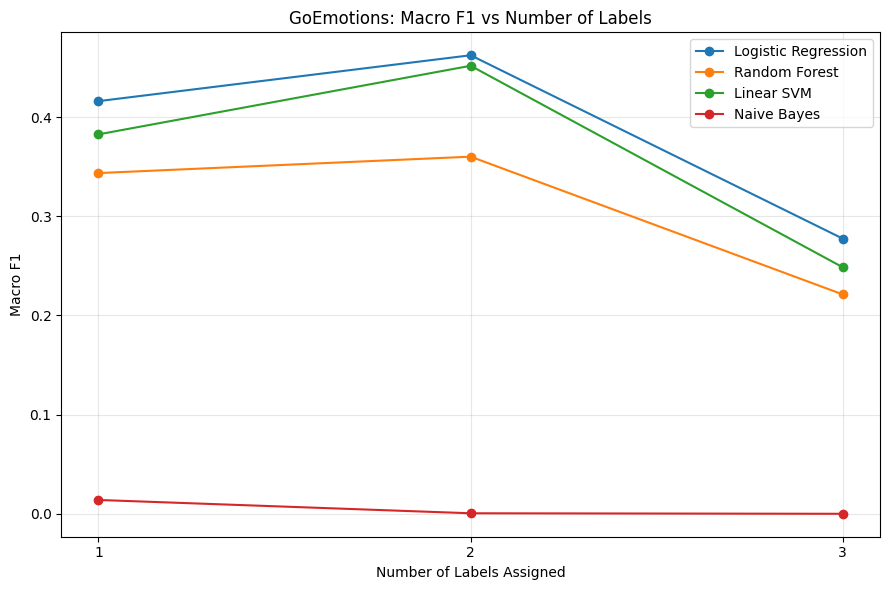

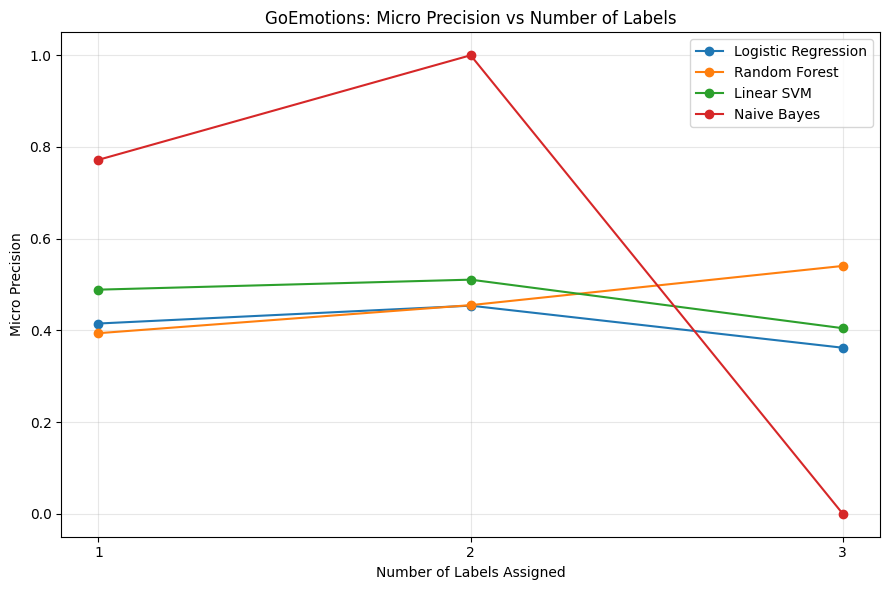

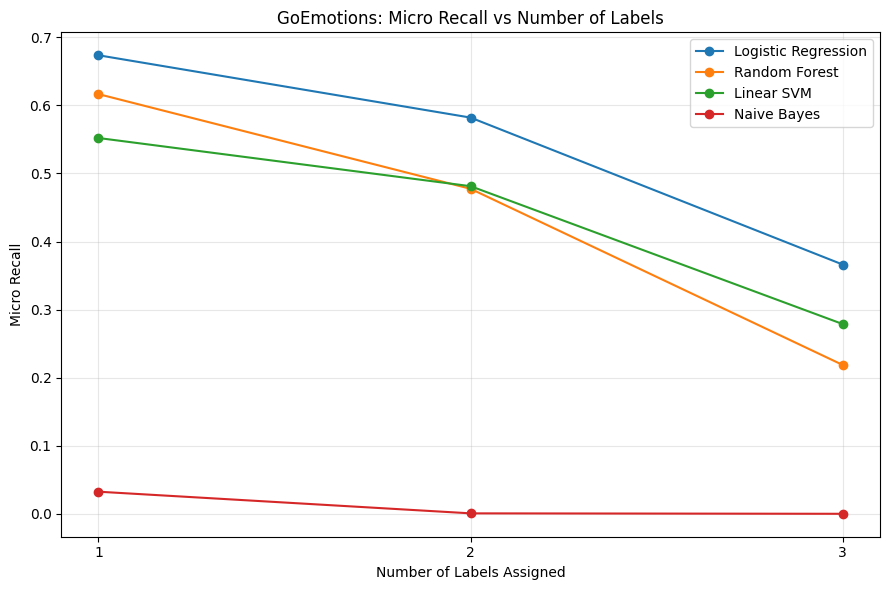

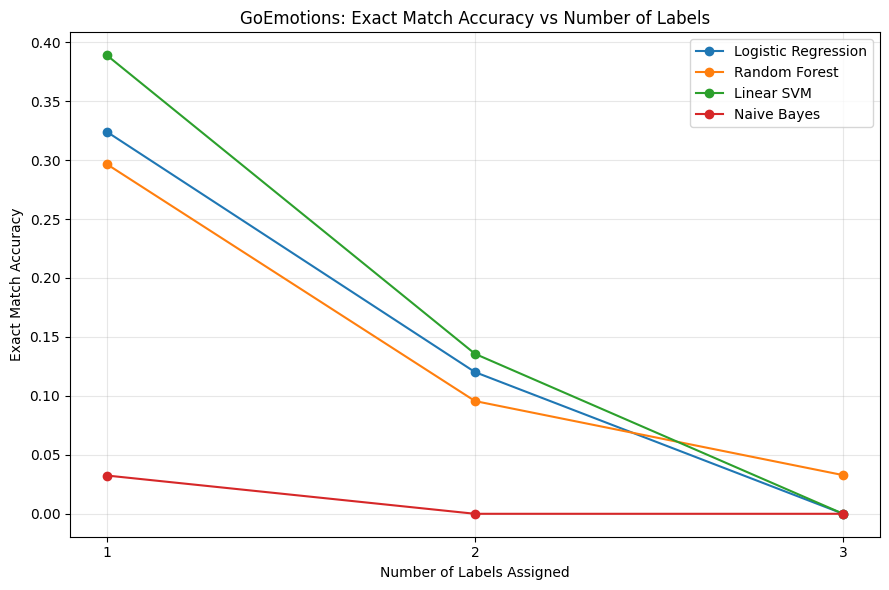

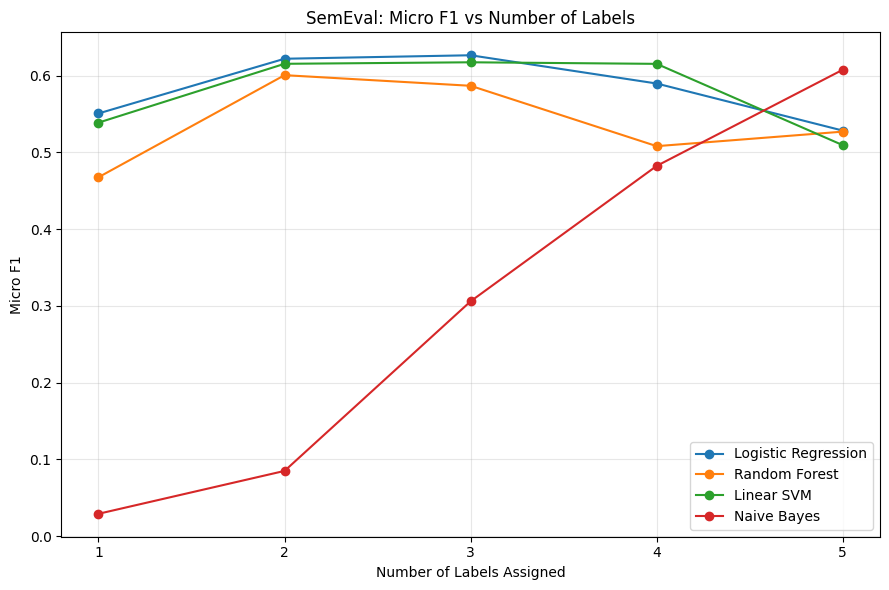

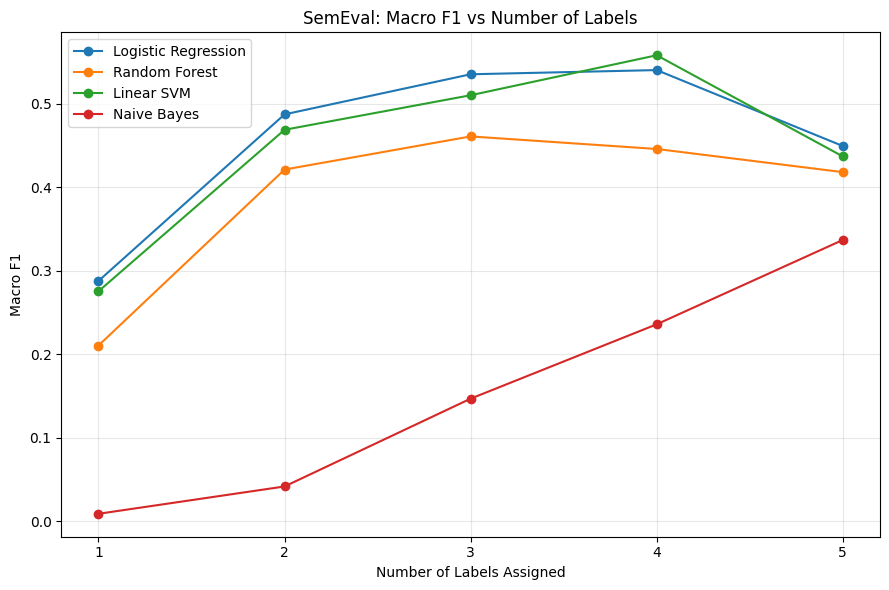

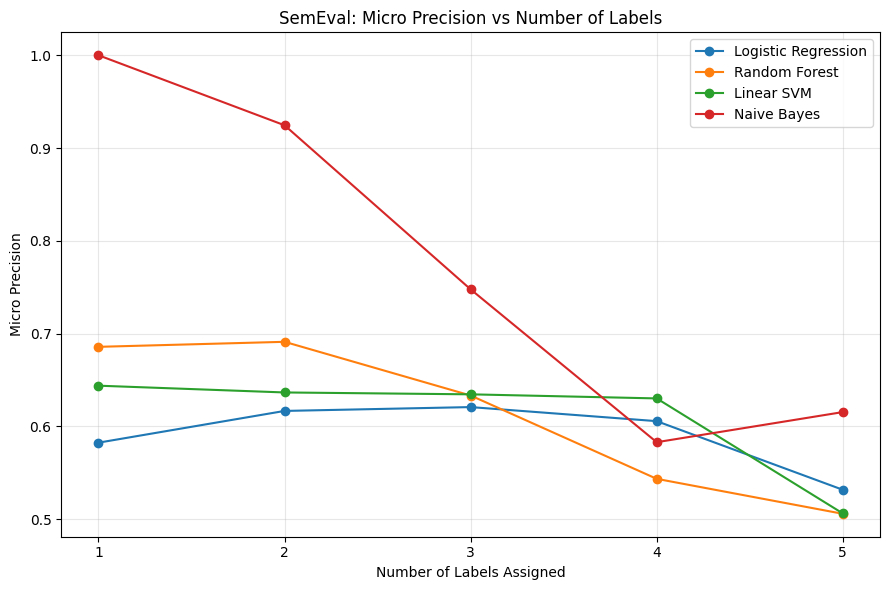

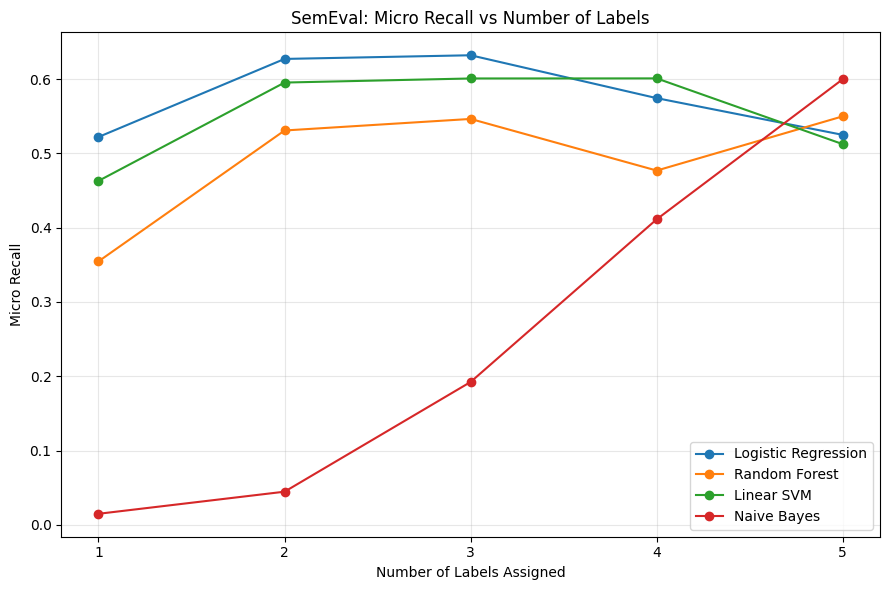

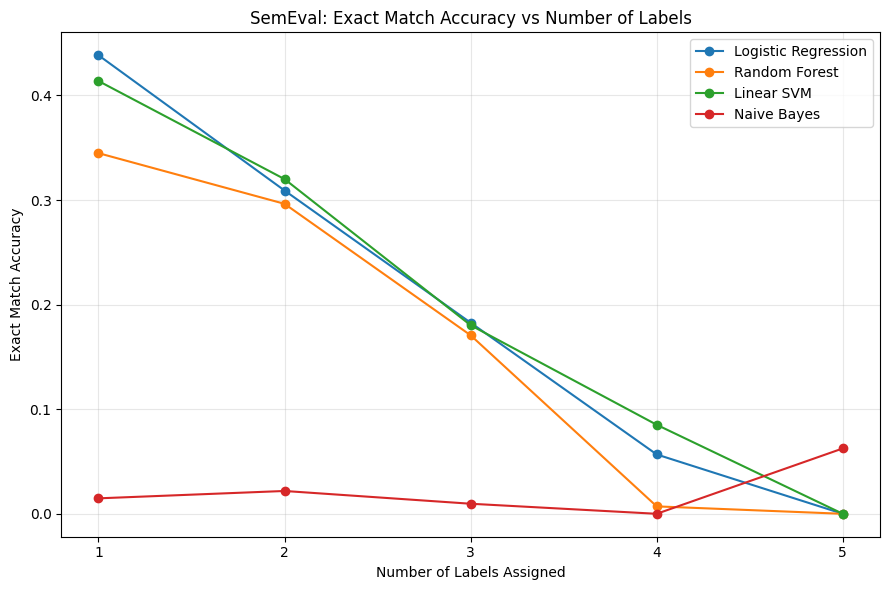

In [142]:
plot_metric_vs_num_labels(
    results_dict=G_label_count_results,
    dataset_name="GoEmotions",
    metrics=metrics_to_plot
)

plot_metric_vs_num_labels(
    results_dict=S_label_count_results,
    dataset_name="SemEval",
    metrics=metrics_to_plot
)


In [143]:
# ------------------------------------------------------------
# GoEmotions Tables
# ------------------------------------------------------------

print("=" * 80)
print("GOEMOTIONS")
print("=" * 80)

for model_name, df in G_label_count_results.items():

    print(f"\n{model_name}")
    print("-" * len(model_name))

    display(
        df.sort_values("Num Labels")
          .reset_index(drop=True)
    )


# ------------------------------------------------------------
# SemEval Tables
# ------------------------------------------------------------

print("=" * 80)
print("SEMEVAL")
print("=" * 80)

for model_name, df in S_label_count_results.items():

    print(f"\n{model_name}")
    print("-" * len(model_name))

    display(
        df.sort_values("Num Labels")
          .reset_index(drop=True)
    )

GOEMOTIONS

Logistic Regression
-------------------


,Num Labels,Train Samples,Test Samples,Micro F1,Macro F1,Micro Precision,Micro Recall,Hamming Loss,Exact Match Accuracy,Training Time (s),Inference Time (s)
0,1,36308,4590,0.513579,0.416177,0.414978,0.673638,0.045573,0.323965,4.391626,0.007496
1,2,6541,774,0.510048,0.462434,0.453904,0.582041,0.079873,0.120155,0.576815,0.003099
2,3,532,61,0.364130,0.277491,0.362162,0.366120,0.137002,0.000000,0.060662,0.002078



Random Forest
-------------


,Num Labels,Train Samples,Test Samples,Micro F1,Macro F1,Micro Precision,Micro Recall,Hamming Loss,Exact Match Accuracy,Training Time (s),Inference Time (s)
0,1,36308,4590,0.480679,0.343624,0.393876,0.616558,0.047580,0.296514,18.387078,0.827857
1,2,6541,774,0.465952,0.360168,0.455049,0.477390,0.078165,0.095607,6.967351,0.399725
2,3,532,61,0.311284,0.221226,0.540541,0.218579,0.103630,0.032787,3.006882,0.387046



Linear SVM
----------


...

,Num Labels,Train Samples,Test Samples,Micro F1,Macro F1,Micro Precision,Micro Recall,Hamming Loss,Exact Match Accuracy,Training Time (s),Inference Time (s)
0,1,779,203,0.467532,0.210297,0.685714,0.354680,0.073444,0.344828,1.275729,0.151679
1,2,2223,550,0.600514,0.420999,0.691124,0.530909,0.128430,0.296364,1.832867,0.163699
2,3,1698,416,0.586667,0.460677,0.633240,0.546474,0.210009,0.170673,1.461936,0.149072
3,4,517,141,0.508026,0.445651,0.543434,0.476950,0.335912,0.007092,1.187213,0.224348
4,5,80,16,0.526946,0.417921,0.505747,0.550000,0.448864,0.000000,0.935054,0.151127



Linear SVM
----------


,Num Labels,Train Samples,Test Samples,Micro F1,Macro F1,Micro Precision,Micro Recall,Hamming Loss,Exact Match Accuracy,Training Time (s),Inference Time (s)
0,1,779,203,0.538682,0.275247,0.643836,0.463054,0.072100,0.413793,0.066290,0.001183
1,2,2223,550,0.615312,0.468635,0.636540,0.595455,0.135372,0.320000,0.406358,0.001345
2,3,1698,416,0.617284,0.509994,0.634518,0.600962,0.203234,0.180288,0.244141,0.001283
3,4,517,141,0.615245,0.557867,0.630112,0.601064,0.273372,0.085106,0.056564,0.001026
4,5,80,16,0.509317,0.436724,0.506173,0.512500,0.448864,0.000000,0.015108,0.001088



Naive Bayes
-----------


,Num Labels,Train Samples,Test Samples,Micro F1,Macro F1,Micro Precision,Micro Recall,Hamming Loss,Exact Match Accuracy,Training Time (s),Inference Time (s)
0,1,779,203,0.029126,0.008798,1.000000,0.014778,0.089566,0.014778,0.012881,0.002037
1,2,2223,550,0.084996,0.041527,0.924528,0.044545,0.174380,0.021818,0.018216,0.002758
2,3,1698,416,0.305927,0.146678,0.747664,0.192308,0.237981,0.009615,0.016938,0.002492
3,4,517,141,0.482328,0.235719,0.582915,0.411348,0.321083,0.000000,0.014412,0.001779
4,5,80,16,0.607595,0.336683,0.615385,0.600000,0.352273,0.062500,0.012263,0.001459
